In [1]:
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(7)
np.random.seed(7)
random.seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)




device: cpu


In [2]:
BATCH_SIZE = 128
TRAIN_LIMIT = None   # e.g. 12000 for a faster demo
TEST_LIMIT = None    # e.g. 2000



In [3]:
#GET MNIST dataset

def load_mnist():
    # First try torchvision.
    try:
        from torchvision import datasets, transforms

        root = Path("./data")
        transform = transforms.ToTensor()

        train_ds = datasets.MNIST(root=root, train=True, download=True, transform=transform)
        test_ds  = datasets.MNIST(root=root, train=False, download=True, transform=transform)

        X_train = train_ds.data.float() / 255.0
        y_train = train_ds.targets.long()
        X_test  = test_ds.data.float() / 255.0
        y_test  = test_ds.targets.long()

        source = "torchvision.datasets.MNIST"
        return X_train, y_train, X_test, y_test, source

    except Exception as e:
        print("torchvision load failed:", repr(e))
        print("Falling back to sklearn.fetch_openml('mnist_784').")

    # Fallback: OpenML
    from sklearn.datasets import fetch_openml

    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X = mnist["data"].astype(np.float32) / 255.0
    y = mnist["target"].astype(np.int64)

    # OpenML version 1 of MNIST follows the standard 60k/10k split.
    X_train = torch.from_numpy(X[:60000]).view(-1, 28, 28)
    y_train = torch.from_numpy(y[:60000]).long()
    X_test  = torch.from_numpy(X[60000:]).view(-1, 28, 28)
    y_test  = torch.from_numpy(y[60000:]).long()

    source = "sklearn.fetch_openml('mnist_784')"
    return X_train, y_train, X_test, y_test, source


X_train_img, y_train, X_test_img, y_test, mnist_source = load_mnist()
print("Loaded from:", mnist_source)
print("Train images:", tuple(X_train_img.shape), "Train labels:", tuple(y_train.shape))
print("Test images :", tuple(X_test_img.shape),  "Test labels :", tuple(y_test.shape))

if TRAIN_LIMIT is not None:
    X_train_img = X_train_img[:TRAIN_LIMIT]
    y_train = y_train[:TRAIN_LIMIT]

if TEST_LIMIT is not None:
    X_test_img = X_test_img[:TEST_LIMIT]
    y_test = y_test[:TEST_LIMIT]

print("\nAfter optional limiting:")
print("Train images:", tuple(X_train_img.shape), "Train labels:", tuple(y_train.shape))
print("Test images :", tuple(X_test_img.shape),  "Test labels :", tuple(y_test.shape))



torchvision load failed: ModuleNotFoundError("No module named 'torchvision'")
Falling back to sklearn.fetch_openml('mnist_784').
Loaded from: sklearn.fetch_openml('mnist_784')
Train images: (60000, 28, 28) Train labels: (60000,)
Test images : (10000, 28, 28) Test labels : (10000,)

After optional limiting:
Train images: (60000, 28, 28) Train labels: (60000,)
Test images : (10000, 28, 28) Test labels : (10000,)


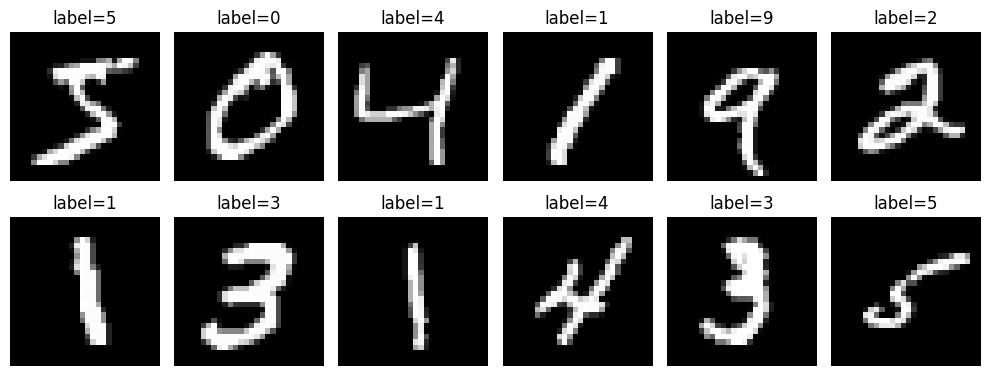

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), range(12)):
    ax.imshow(X_train_img[idx].numpy(), cmap="gray")
    ax.set_title(f"label={int(y_train[idx])}")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [5]:
# Flatten images to vectors of length 784.
X_train_flat = X_train_img.view(len(X_train_img), -1)
X_test_flat  = X_test_img.view(len(X_test_img), -1)

train_clf_ds = TensorDataset(X_train_flat, y_train)
test_clf_ds  = TensorDataset(X_test_flat, y_test)

train_clf_loader = DataLoader(train_clf_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_clf_loader  = DataLoader(test_clf_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(train_clf_loader))
print("One minibatch of inputs:", xb.shape)
print("One minibatch of labels:", yb.shape)


One minibatch of inputs: torch.Size([128, 784])
One minibatch of labels: torch.Size([128])


In [6]:
class MNISTFeedForward(nn.Module):
    def __init__(self, input_dim=28*28, hidden_dim=75, num_classes=10):
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.act = nn.ReLU()
        self.output = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        h = self.hidden(x)
        h = self.act(h)
        logits = self.output(h)
        return logits


clf_model = MNISTFeedForward().to(device)
clf_model



MNISTFeedForward(
  (hidden): Linear(in_features=784, out_features=75, bias=True)
  (act): ReLU()
  (output): Linear(in_features=75, out_features=10, bias=True)
)

In [7]:
# Walk through a single forward pass carefully.
xb, yb = next(iter(train_clf_loader))
xb = xb.to(device)

with torch.no_grad():
    h_pre = clf_model.hidden(xb)
    h = clf_model.act(h_pre)
    logits = clf_model.output(h)

print("input shape            :", tuple(xb.shape))
print("after hidden linear    :", tuple(h_pre.shape))
print("after ReLU             :", tuple(h.shape))
print("after output linear    :", tuple(logits.shape))
print("example logits for item 0:")
print(logits[0].cpu())




input shape            : (128, 784)
after hidden linear    : (128, 75)
after ReLU             : (128, 75)
after output linear    : (128, 10)
example logits for item 0:
tensor([ 0.1841, -0.0190,  0.0997,  0.0527,  0.0789,  0.1781, -0.0962, -0.0350,
        -0.1658, -0.0609])


In [8]:
def run_classifier_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = F.cross_entropy(logits, yb)

        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_examples += xb.size(0)

    return total_loss / total_examples, total_correct / total_examples


def train_classifier(model, train_loader, test_loader, epochs=5, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_classifier_epoch(model, train_loader, optimizer=optimizer)
        test_loss, test_acc = run_classifier_epoch(model, test_loader, optimizer=None)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"epoch {epoch:02d} | "
            f"train loss {train_loss:.4f} | train acc {train_acc:.4f} | "
            f"test loss {test_loss:.4f} | test acc {test_acc:.4f}"
        )
    return history



In [9]:

clf_history = train_classifier(
    clf_model,
    train_clf_loader,
    test_clf_loader,
    epochs=5,
    lr=1e-3,
)




epoch 01 | train loss 0.4663 | train acc 0.8792 | test loss 0.2518 | test acc 0.9281
epoch 02 | train loss 0.2252 | train acc 0.9353 | test loss 0.1857 | test acc 0.9465
epoch 03 | train loss 0.1697 | train acc 0.9521 | test loss 0.1536 | test acc 0.9560
epoch 04 | train loss 0.1363 | train acc 0.9613 | test loss 0.1304 | test acc 0.9621
epoch 05 | train loss 0.1126 | train acc 0.9678 | test loss 0.1139 | test acc 0.9668


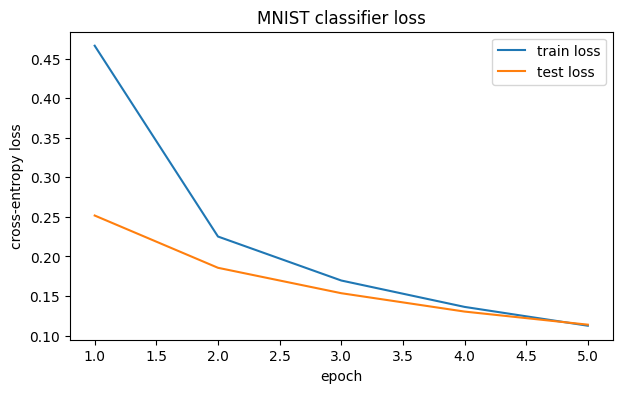

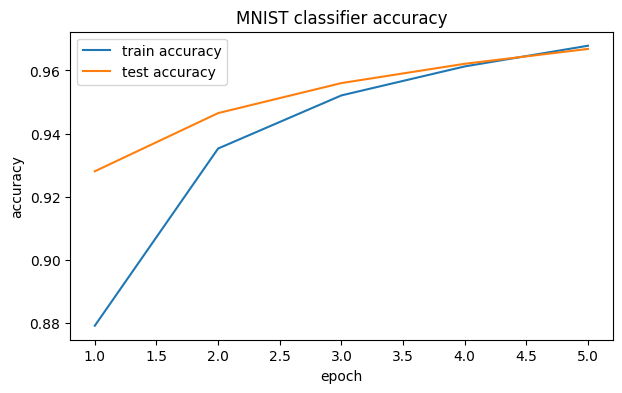

In [10]:
epochs = np.arange(1, len(clf_history["train_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, clf_history["train_loss"], label="train loss")
plt.plot(epochs, clf_history["test_loss"], label="test loss")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.legend()
plt.title("MNIST classifier loss")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, clf_history["train_acc"], label="train accuracy")
plt.plot(epochs, clf_history["test_acc"], label="test accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("MNIST classifier accuracy")
plt.show()



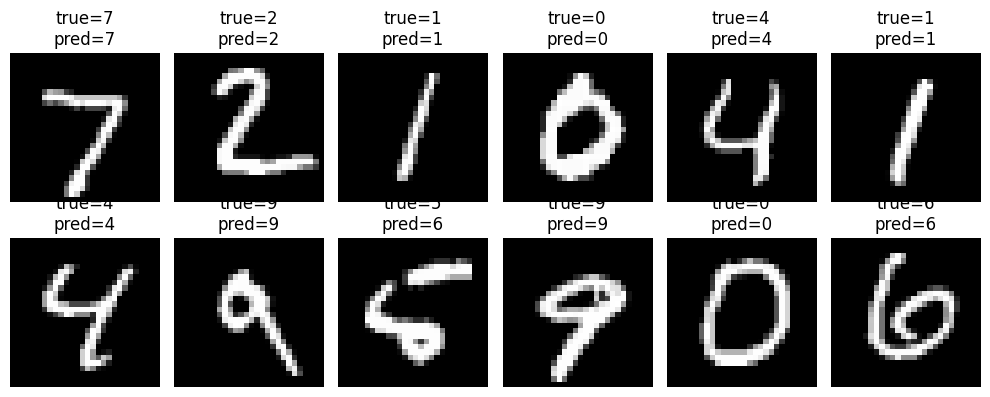

In [11]:
# Visualize a few test predictions.
clf_model.eval()

xb, yb = next(iter(test_clf_loader))
xb = xb.to(device)
with torch.no_grad():
    logits = clf_model(xb)
    preds = logits.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, img, true_y, pred_y in zip(axes.ravel(), xb.cpu(), yb, preds):
    ax.imshow(img.view(28, 28), cmap="gray")
    ax.set_title(f"true={int(true_y)}\npred={int(pred_y)}")
    ax.axis("off")
plt.tight_layout()
plt.show()


Autoencoder demo (singular value decomposition)

In [12]:
# Synthetic matrix
n = 1000
m = 50
k = 10

X = torch.randn(n, m)
U, S, Vh = torch.linalg.svd(X, full_matrices=True)

# Make the singular spectrum decay so the low-rank structure is easier to see.
weights = torch.tensor([1.1 ** (-i) for i in range(len(S))], dtype=S.dtype)
S_tilted = S * weights

X = U[:, :m] @ torch.diag(S_tilted) @ Vh
X = X - X.mean(dim=0, keepdim=True)

print("X shape:", tuple(X.shape))
print("Top 15 singular values of centered X:")
print(torch.linalg.svdvals(X)[:15])



X shape: (1000, 50)
Top 15 singular values of centered X:
tensor([37.7954, 34.2181, 30.5469, 27.6284, 24.9149, 22.5256, 20.1565, 18.2467,
        16.4694, 14.7548, 13.3600, 12.1007, 10.9231,  9.8718,  8.9313])


In [13]:
class TiedLinearAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Linear(input_dim, latent_dim, bias=False)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        # F.linear(z, A) computes z @ A^T.
        # To obtain z @ W, pass A = W^T.
        return F.linear(z, self.encoder.weight.t())

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat


def train_autoencoder(model, loader, epochs=20, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_examples = 0

        for (xb,) in loader:
            xb = xb.to(device)
            x_hat = model(xb)
            loss = F.mse_loss(x_hat, xb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_examples += xb.size(0)

        avg_loss = total_loss / total_examples
        history.append(avg_loss)
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(f"epoch {epoch:02d} | mse {avg_loss:.6f}")

    return history



In [14]:
synthetic_loader = DataLoader(
    TensorDataset(X.float()),
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

svd_model = TiedLinearAutoencoder(input_dim=m, latent_dim=k).to(device)
svd_history = train_autoencoder(svd_model, synthetic_loader, epochs=100, lr=1e-3)



epoch 01 | mse 0.127185
epoch 05 | mse 0.074756
epoch 10 | mse 0.044742
epoch 15 | mse 0.030828
epoch 20 | mse 0.024469
epoch 25 | mse 0.021713
epoch 30 | mse 0.020465
epoch 35 | mse 0.019912
epoch 40 | mse 0.019654
epoch 45 | mse 0.019542
epoch 50 | mse 0.019472
epoch 55 | mse 0.019447
epoch 60 | mse 0.019427
epoch 65 | mse 0.019422
epoch 70 | mse 0.019413
epoch 75 | mse 0.019415
epoch 80 | mse 0.019420
epoch 85 | mse 0.019426
epoch 90 | mse 0.019418
epoch 95 | mse 0.019422
epoch 100 | mse 0.019415


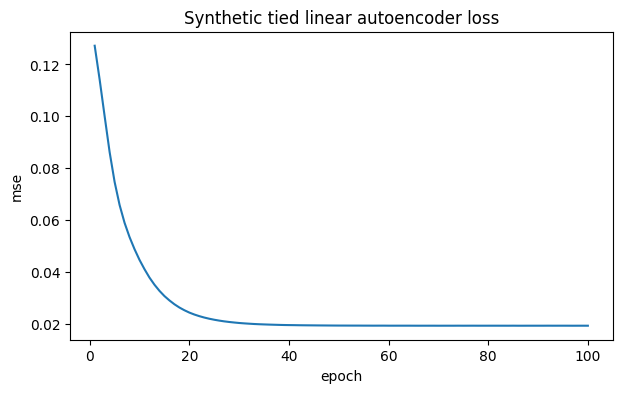

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(svd_history) + 1), svd_history)
plt.xlabel("epoch")
plt.ylabel("mse")
plt.title("Synthetic tied linear autoencoder loss")
plt.show()



In [16]:
# %% [markdown]
# ## Compare the learned weights to the top singular subspace
#
# Let \(V_k \in \mathbb{R}^{m\times k}\) be the top \(k\) right singular vectors of \(X\).
#
# The matrix `W = encoder.weight` has shape `(k, m)`, so the **columns of** \(W^\top\) span the learned \(k\)-dimensional subspace.
#
# We check three things:
# 1. `W @ W.T` is close to identity: the learned rows are close to orthonormal.
# 2. The projection matrix from the learned subspace is close to the rank-\(k\) SVD projector.
# 3. The singular values of \(V_k^\top W^\top\) are close to 1 if the subspaces line up.


# %%

with torch.no_grad():
    W = svd_model.encoder.weight.detach().cpu()               # shape (k, m)
    V_k = torch.linalg.svd(X, full_matrices=False).Vh[:k].T  # shape (m, k)

    row_gram = W @ W.T

    # Projector onto span(W^T). Use pseudo-inverse in case the rows are not perfectly orthonormal.
    P_W = W.T @ torch.linalg.pinv(W @ W.T) @ W
    P_V = V_k @ V_k.T

    projector_error = torch.linalg.norm(P_W - P_V).item()

    overlap = V_k.T @ W.T
    overlap_svals = torch.linalg.svdvals(overlap)

print("W shape:", tuple(W.shape))
print("\nRow Gram matrix W W^T (should be close to I_k):")
print(torch.round(row_gram, decimals=1))
print("\n||P_W - P_V||_F =", round(projector_error, 3))
print("\nSingular values of V_k^T W^T (closer to 1 means better alignment):")
print(torch.round(overlap_svals, decimals=4))



W shape: (10, 50)

Row Gram matrix W W^T (should be close to I_k):
tensor([[1., 0., 0., -0., 0., 0., 0., -0., 0., -0.],
        [0., 1., 0., 0., -0., -0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., -0., -0., -0., -0., 0.],
        [-0., 0., 0., 1., -0., -0., -0., -0., 0., -0.],
        [0., -0., 0., -0., 1., 0., -0., -0., 0., 0.],
        [0., -0., -0., -0., 0., 1., 0., -0., -0., -0.],
        [0., 0., -0., -0., -0., 0., 1., -0., 0., 0.],
        [-0., 0., -0., -0., -0., -0., -0., 1., -0., 0.],
        [0., 0., -0., 0., 0., -0., 0., -0., 1., 0.],
        [-0., 0., 0., -0., 0., -0., 0., 0., 0., 1.]])

||P_W - P_V||_F = 0.025

Singular values of V_k^T W^T (closer to 1 means better alignment):
tensor([1.0005, 1.0004, 1.0003, 1.0002, 1.0001, 1.0000, 0.9999, 0.9998, 0.9997,
        0.9997])


In [17]:
# Center the training and test vectors using the training mean.
mnist_mean = X_train_flat.mean(dim=0, keepdim=True)
X_train_centered = X_train_flat - mnist_mean
X_test_centered  = X_test_flat - mnist_mean

train_ae_loader = DataLoader(
    TensorDataset(X_train_centered),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

test_ae_loader = DataLoader(
    TensorDataset(X_test_centered),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print("Centered train matrix:", tuple(X_train_centered.shape))
print("Centered test matrix :", tuple(X_test_centered.shape))


Centered train matrix: (60000, 784)
Centered test matrix : (10000, 784)


In [18]:
mnist_ae = TiedLinearAutoencoder(input_dim=28*28, latent_dim=10).to(device)
mnist_ae_history = train_autoencoder(mnist_ae, train_ae_loader, epochs=50, lr=1e-3)


epoch 01 | mse 0.038467
epoch 05 | mse 0.034531
epoch 10 | mse 0.034531
epoch 15 | mse 0.034530
epoch 20 | mse 0.034532
epoch 25 | mse 0.034529
epoch 30 | mse 0.034530
epoch 35 | mse 0.034528
epoch 40 | mse 0.034529
epoch 45 | mse 0.034528
epoch 50 | mse 0.034528


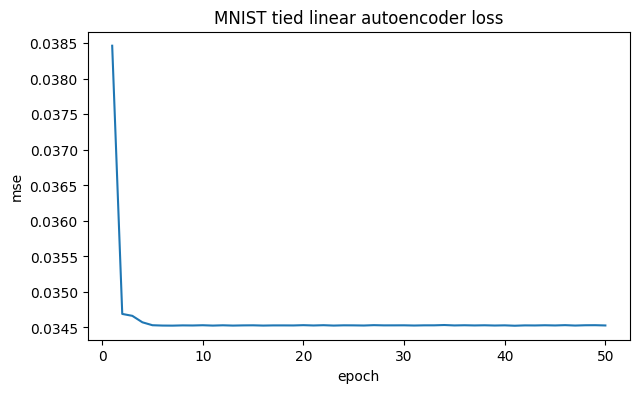

In [19]:

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(mnist_ae_history) + 1), mnist_ae_history)
plt.xlabel("epoch")
plt.ylabel("mse")
plt.title("MNIST tied linear autoencoder loss")
plt.show()




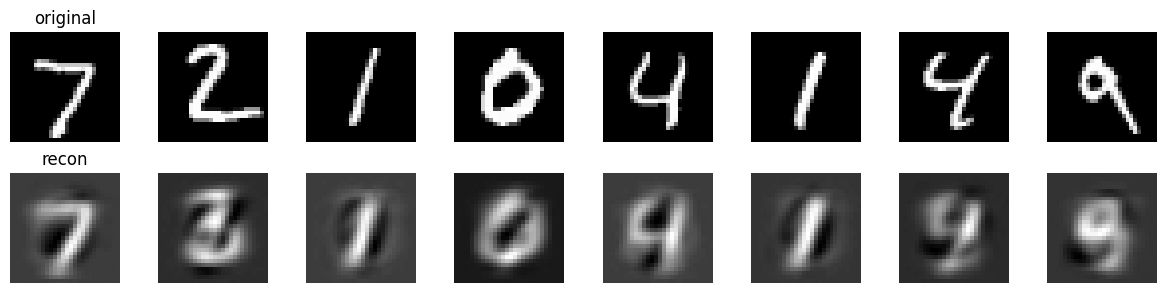

In [20]:
# Visualize reconstructions on a test minibatch.
mnist_ae.eval()

xb = next(iter(test_ae_loader))[0][:8].to(device)
with torch.no_grad():
    z = mnist_ae.encode(xb)
    x_hat_centered = mnist_ae.decode(z)
    x_hat = x_hat_centered + mnist_mean.to(device)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow((xb[i] + mnist_mean.to(device)[0]).cpu().view(28, 28), cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("original")

    axes[1, i].imshow(x_hat[i].cpu().view(28, 28), cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("recon")

plt.tight_layout()
plt.show()


In [21]:

def encode_dataset(model, loader):
    model.eval()
    zs = []
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            z = model.encode(xb)
            zs.append(z.cpu())
    return torch.cat(zs, dim=0)


train_latent_loader = DataLoader(
    TensorDataset(X_train_centered),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_latent_loader = DataLoader(
    TensorDataset(X_test_centered),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

Z_train = encode_dataset(mnist_ae, train_latent_loader)
Z_test = encode_dataset(mnist_ae, test_latent_loader)

print("Z_train shape:", tuple(Z_train.shape))
print("Z_test shape :", tuple(Z_test.shape))
print("First training latent vector:")
print(torch.round(Z_train[0], decimals=4))



Z_train shape: (60000, 10)
Z_test shape : (10000, 10)
First training latent vector:
tensor([-1.9274, -0.2410,  0.4271,  0.4363, -0.7387, -1.3955, -0.7583, -0.7087,
        -0.5438, -1.7346])


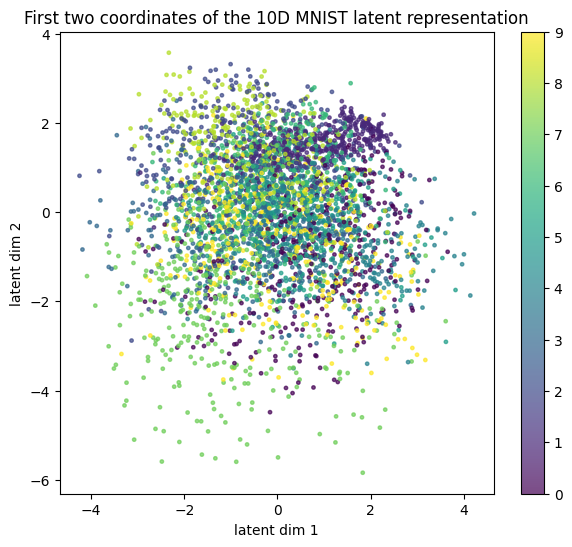

In [22]:

# Optional: quick look at the first two latent coordinates for a subset of the training data.
subset = min(4000, len(Z_train))
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    Z_train[:subset, 0].numpy(),
    Z_train[:subset, 1].numpy(),
    c=y_train[:subset].numpy(),
    s=6,
    alpha=0.7,
)
plt.colorbar(scatter)
plt.xlabel("latent dim 1")
plt.ylabel("latent dim 2")
plt.title("First two coordinates of the 10D MNIST latent representation")
plt.show()




In [45]:
class ReLUTiedAutoencoder(TiedLinearAutoencoder):
    def __init__(self, input_dim=28*28, latent_dim=10):
        super().__init__(input_dim=input_dim, latent_dim=256)
        self.hidden_one = nn.Linear(256, 128)
        self.hidden_two = nn.Linear(128, latent_dim)
        self.relu = nn.ReLU()

    def encode(self, x):
        z = super().encode(x)
        z = self.relu(z)
        z = self.hidden_one(z)
        z = self.relu(z)
        z = self.hidden_two(z)
        z = self.relu(z)
        return z

    def decode(self, x):
        z = F.linear(x, self.hidden_two.weight.t())
        z = self.relu(z)
        z = F.linear(z, self.hidden_one.weight.t())
        z = self.relu(z)
        z = super().decode(z)
        return z

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat

In [46]:
relu_tied_mnist_ae = ReLUTiedAutoencoder(
    input_dim=28*28,
    latent_dim=10,
).to(device)

train_latent_loader = DataLoader(
    TensorDataset(X_train_centered),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_latent_loader = DataLoader(
    TensorDataset(X_test_centered),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

relu_tied_history = train_autoencoder(
    relu_tied_mnist_ae,
    train_latent_loader,
    epochs=20,
    lr=1e-3,
)

epoch 01 | mse 0.037273
epoch 05 | mse 0.021062
epoch 10 | mse 0.019237
epoch 15 | mse 0.018397
epoch 20 | mse 0.017893


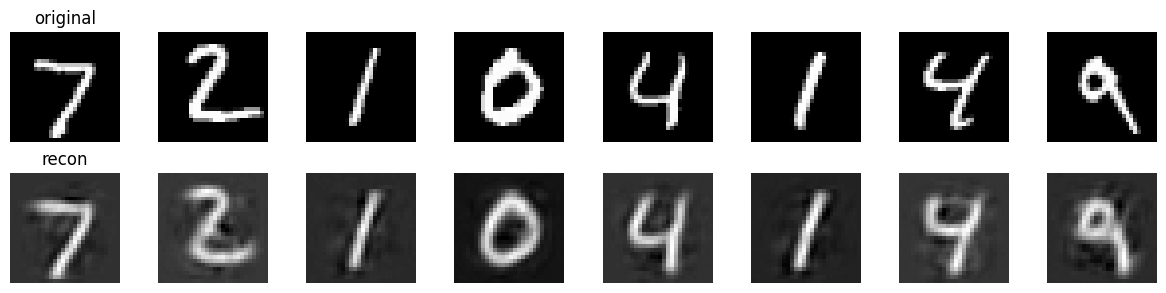

In [47]:
relu_tied_mnist_ae.eval()

xb = next(iter(test_ae_loader))[0][:8].to(device)
with torch.no_grad():
    z = relu_tied_mnist_ae.encode(xb)
    x_hat_centered= relu_tied_mnist_ae.decode(z)
    x_hat = x_hat_centered + mnist_mean.to(device)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow((xb[i] + mnist_mean.to(device)[0]).cpu().view(28, 28), cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("original")

    axes[1, i].imshow(x_hat[i].cpu().view(28, 28), cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("recon")

plt.tight_layout()
plt.show()

Sampled latent z:
tensor([-0.4570, -0.1510,  0.1640, -0.1710,  0.1000,  0.8640, -0.5300,  0.0420,
         1.8780,  0.8110])


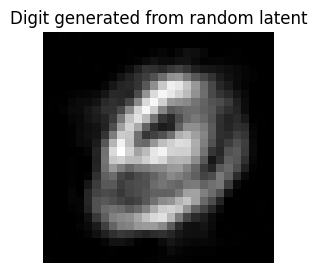

In [53]:
'''
The latent vectors are however in a complicated space.
If we arbitrary generate a length 10 vector, the reconstruction is probably meaningless as we show here.
'''

relu_tied_mnist_ae.eval()

with torch.no_grad():
    z = torch.randn(1, 10, device=device)   # new latent sample
    x_centered = relu_tied_mnist_ae.decode(z)
    x = x_centered + mnist_mean.to(device)
    x = torch.clamp(x, 0.0, 1.0)

print("Sampled latent z:")
print(torch.round(z[0].cpu(), decimals=3))

plt.figure(figsize=(3, 3))
plt.imshow(x[0].cpu().view(28, 28), cmap="gray")
plt.title("Digit generated from random latent")
plt.axis("off")
plt.show()

In [27]:
# Variational Autoencoder

class VariationalReLUTiedAutoencoder(TiedLinearAutoencoder):
    def __init__(self, input_dim=28*28, latent_dim=10):
        # same first tied block as before: input_dim -> 256
        super().__init__(input_dim=input_dim, latent_dim=256)

        # shared nonlinear hidden layer
        self.hidden_one = nn.Linear(256, 256)

        # two heads instead of one:
        # mean and log-variance of q(z|x)
        self.mu_head = nn.Linear(256, latent_dim)
        self.logvar_head = nn.Linear(256, latent_dim)

        self.relu = nn.ReLU()

    def encode_features(self, x):
        # deterministic shared encoder trunk
        h = super().encode(x)      # input_dim -> 256 (tied to final decode layer)
        h = self.relu(h)
        h = self.hidden_one(h)     # 256 -> 256
        h = self.relu(h)
        return h

    def encode_distribution(self, x):
        h = self.encode_features(x)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # z = mu + std * eps
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def encode(self, x):
        # for compatibility with old helper code:
        # return the mean latent code
        mu, logvar = self.encode_distribution(x)
        return mu

    def decode(self, z):
        # pedagogical tying:
        # use transpose of mu_head to go latent_dim -> 256
        h = F.linear(z, self.mu_head.weight.t())
        h = self.relu(h)

        # tie hidden_one in reverse
        h = F.linear(h, self.hidden_one.weight.t())
        h = self.relu(h)

        # final tied decode from parent: 256 -> input_dim
        x_hat = super().decode(h)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode_distribution(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

In [28]:
def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    # Reconstruction term: Gaussian decoder with fixed variance
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)

    # KL(q(z|x) || N(0,I))
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

    loss = recon + beta * kl
    return loss, recon, kl

In [29]:
def train_vae(model, train_loader, test_loader, epochs=20, lr=1e-3, beta=1.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_recon": [],
        "train_kl": [],
        "test_loss": [],
        "test_recon": [],
        "test_kl": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0
        total_examples = 0

        for (xb,) in train_loader:
            xb = xb.to(device)

            x_hat, mu, logvar = model(xb)
            loss, recon, kl = vae_loss(xb, x_hat, mu, logvar, beta=beta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = xb.size(0)
            total_loss += loss.item() * batch_size
            total_recon += recon.item() * batch_size
            total_kl += kl.item() * batch_size
            total_examples += batch_size

        train_loss = total_loss / total_examples
        train_recon = total_recon / total_examples
        train_kl = total_kl / total_examples

        model.eval()
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0
        total_examples = 0

        with torch.no_grad():
            for (xb,) in test_loader:
                xb = xb.to(device)

                x_hat, mu, logvar = model(xb)
                loss, recon, kl = vae_loss(xb, x_hat, mu, logvar, beta=beta)

                batch_size = xb.size(0)
                total_loss += loss.item() * batch_size
                total_recon += recon.item() * batch_size
                total_kl += kl.item() * batch_size
                total_examples += batch_size

        test_loss = total_loss / total_examples
        test_recon = total_recon / total_examples
        test_kl = total_kl / total_examples

        history["train_loss"].append(train_loss)
        history["train_recon"].append(train_recon)
        history["train_kl"].append(train_kl)
        history["test_loss"].append(test_loss)
        history["test_recon"].append(test_recon)
        history["test_kl"].append(test_kl)

        print(
            f"epoch {epoch:02d} | "
            f"train loss {train_loss:.4f} | recon {train_recon:.4f} | kl {train_kl:.4f} | "
            f"test loss {test_loss:.4f} | recon {test_recon:.4f} | kl {test_kl:.4f}"
        )

    return history

In [30]:
vae_model = VariationalReLUTiedAutoencoder(
    input_dim=28*28,
    latent_dim=10,
).to(device)

vae_history = train_vae(
    vae_model,
    train_ae_loader,
    test_ae_loader,
    epochs=20,
    lr=1e-3,
    beta=1.0,
)

epoch 01 | train loss 40.6636 | recon 35.4630 | kl 5.2006 | test loss 35.1142 | recon 28.1021 | kl 7.0121
epoch 02 | train loss 34.2635 | recon 26.7367 | kl 7.5267 | test loss 33.1771 | recon 25.2134 | kl 7.9636
epoch 03 | train loss 32.9102 | recon 24.7906 | kl 8.1196 | test loss 32.3403 | recon 23.9729 | kl 8.3674
epoch 04 | train loss 32.2539 | recon 23.8675 | kl 8.3863 | test loss 31.7449 | recon 23.1796 | kl 8.5653
epoch 05 | train loss 31.8223 | recon 23.2803 | kl 8.5420 | test loss 31.4692 | recon 22.6906 | kl 8.7786
epoch 06 | train loss 31.5319 | recon 22.8661 | kl 8.6658 | test loss 31.1933 | recon 22.3738 | kl 8.8195
epoch 07 | train loss 31.3085 | recon 22.5442 | kl 8.7643 | test loss 31.0805 | recon 22.2141 | kl 8.8664
epoch 08 | train loss 31.1160 | recon 22.3035 | kl 8.8125 | test loss 30.9984 | recon 22.3907 | kl 8.6076
epoch 09 | train loss 30.9652 | recon 22.0741 | kl 8.8910 | test loss 30.8072 | recon 21.4773 | kl 9.3299
epoch 10 | train loss 30.8630 | recon 21.9333 

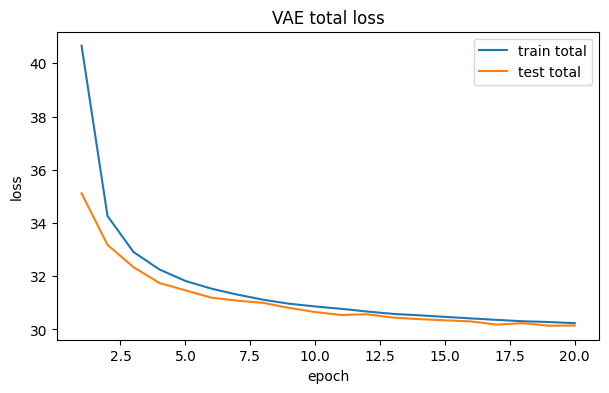

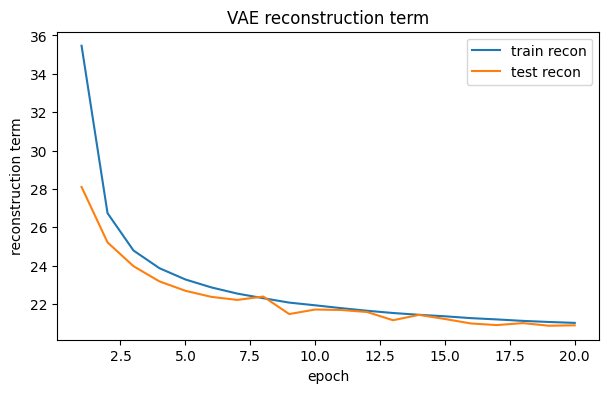

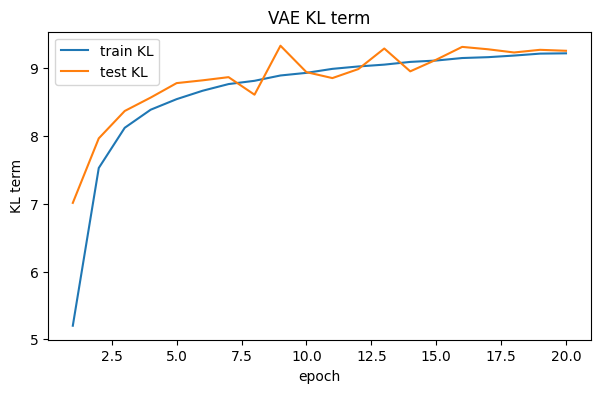

In [31]:
epochs = np.arange(1, len(vae_history["train_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, vae_history["train_loss"], label="train total")
plt.plot(epochs, vae_history["test_loss"], label="test total")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("VAE total loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, vae_history["train_recon"], label="train recon")
plt.plot(epochs, vae_history["test_recon"], label="test recon")
plt.xlabel("epoch")
plt.ylabel("reconstruction term")
plt.title("VAE reconstruction term")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, vae_history["train_kl"], label="train KL")
plt.plot(epochs, vae_history["test_kl"], label="test KL")
plt.xlabel("epoch")
plt.ylabel("KL term")
plt.title("VAE KL term")
plt.legend()
plt.show()

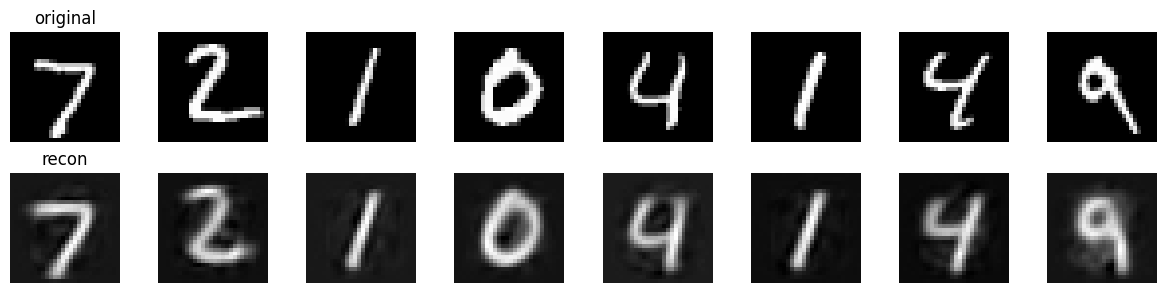

In [32]:
vae_model.eval()

xb = next(iter(test_ae_loader))[0][:8].to(device)
with torch.no_grad():
    mu, logvar = vae_model.encode_distribution(xb)
    x_hat_centered = vae_model.decode(mu)   # deterministic reconstruction from mean
    x_hat = x_hat_centered + mnist_mean.to(device)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow((xb[i] + mnist_mean.to(device)[0]).cpu().view(28, 28), cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("original")

    axes[1, i].imshow(x_hat[i].cpu().view(28, 28), cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("recon")

plt.tight_layout()
plt.show()

Sampled latent z:
tensor([-0.2940, -0.5070,  0.7000,  0.7150,  0.5640,  0.3020,  0.9810,  1.6080,
        -0.0380,  0.2770])


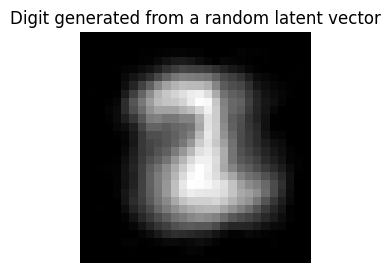

In [79]:
# Show one sampled latent vector and the generated image

vae_model.eval()

with torch.no_grad():
    z = torch.randn(1, 10, device=device)   # new latent sample
    x_centered = vae_model.decode(z)
    x = x_centered + mnist_mean.to(device)
    x = torch.clamp(x, 0.0, 1.0)

print("Sampled latent z:")
print(torch.round(z[0].cpu(), decimals=3))

plt.figure(figsize=(3, 3))
plt.imshow(x[0].cpu().view(28, 28), cmap="gray")
plt.title("Digit generated from a random latent vector")
plt.axis("off")
plt.show()